In [14]:
import os
from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.evaluation import RegressionEvaluator

In [15]:
spark = (SparkSession.builder
         .appName("Seattle911-ResponseTime")
         .getOrCreate())

In [16]:
DATA = os.path.join("..", "data", "processed", "calldata_20251019_processed_v4.csv")
df = (spark.read.option("header", True).option("inferSchema", True).csv(DATA))

In [17]:
label_col = "call_sign_total_service_time_s"
df = df.filter(F.col(label_col).isNotNull())
df = df.filter(
    (F.col("dispatch_neighborhood").isNotNull()) &
    (F.col("dispatch_sector").isNotNull()) &
    (F.col("dispatch_latitude").isNotNull()) &
    (F.col("dispatch_longitude").isNotNull()) &
    (~F.col("dispatch_neighborhood").like("%REDACTED%")) &
    (~F.col("dispatch_sector").like("%REDACTED%"))&
    (~F.col("dispatch_latitude").like("%REDACTED%")) &
    (~F.col("dispatch_longitude").like("%REDACTED%"))
)

In [18]:
raw_feats = [
    "priority",
    "call_type",
    "dispatch_neighborhood",
    "dispatch_sector",
    "dispatch_latitude",
    "dispatch_longitude",
    "cad_event_original_time_queued_datetime_hour",
    "count_of_officers",
    "pseudo_priority_score",
]

num_feats = [
    "priority", "dispatch_latitude", "dispatch_longitude",
    "cad_event_original_time_queued_datetime_hour",
    "count_of_officers", "pseudo_priority_score"
]

for c in num_feats:
    df = df.withColumn(c, F.col(c).cast("double"))

In [19]:
df[num_feats].show(5)

+--------+-----------------+------------------+--------------------------------------------+-----------------+---------------------+
|priority|dispatch_latitude|dispatch_longitude|cad_event_original_time_queued_datetime_hour|count_of_officers|pseudo_priority_score|
+--------+-----------------+------------------+--------------------------------------------+-----------------+---------------------+
|     1.0|      47.52477767|     -122.32692118|                                         3.0|              1.0|    2.450716813539316|
|     3.0|      47.55579822|     -122.28336528|                                         3.0|              1.0|    2.450716813539316|
|     3.0|      47.60878866|     -122.33844952|                                         3.0|              1.0|    2.891034242830873|
|     2.0|      47.59829028|     -122.33326143|                                         3.0|              1.0|     3.13971946759172|
|     3.0|      47.62917261|     -122.35507492|                      

In [20]:
cat_feats = ["call_type", "dispatch_neighborhood", "dispatch_sector"]

indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
            for c in cat_feats]
encoders = [OneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_vec"])
            for c in cat_feats]

assembled_feats = (
    [f"{c}_vec" for c in cat_feats] +
    num_feats
)

In [21]:
# Assembling for Spark ML models

assembler = VectorAssembler(inputCols=assembled_feats, outputCol="features")

stages = indexers + encoders + [assembler]
base_pipe = Pipeline(stages=stages)
prepared = base_pipe.fit(df).transform(df).select("features", F.col(label_col).alias("label"))

train, test = prepared.randomSplit([0.8, 0.2], seed=42)

In [22]:
from xgboost.spark import SparkXGBRegressor

xgb = SparkXGBRegressor(
    features_col="features",
    label_col="label",
    num_workers= max(1, len(spark.sparkContext._jsc.sc().statusTracker().getExecutorInfos())-1),
    n_estimators=350,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    learning_rate=0.05,
    reg_lambda=1.0,
    objective="reg:squarederror"
)

xgb_model = xgb.fit(train)
xgb_pred  = xgb_model.transform(test)

2025-10-31 18:20:06,550 INFO XGBoost-PySpark: _fit Running xgboost-2.1.1 on 1 workers with
	booster params: {'objective': 'reg:squarederror', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.05, 'max_depth': 8, 'reg_lambda': 1.0, 'subsample': 0.8, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 350}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2025-10-31 18:20:09,925 INFO XGBoost-PySpark: _train_booster Training on CPUs 1]
[18:20:10] Task 0 got rank 0
2025-10-31 18:20:25,288 INFO XGBoost-PySpark: _fit Finished xgboost training!   


In [23]:
# #NOT WORKING PROPERLY RIGHT NOW

# from synapse.ml.lightgbm import LightGBMRegressor

# lgbm = LightGBMRegressor(
#     featuresCol="features",
#     labelCol="label",
#     objective="regression",
#     numLeaves=63,
#     learningRate=0.05,
#     numIterations=350,
#     baggingFraction=0.8,
#     featureFraction=0.8
# )
# lgbm_model = lgbm.fit(train)
# lgbm_pred  = lgbm_model.transform(test)

In [31]:
# Eval

e_mae = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")
e_rmse= RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
e_mse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mse")

print("XGB  MAE:", e_mae.evaluate(xgb_pred),  " RMSE:", e_rmse.evaluate(xgb_pred), " MSE:", e_mse.evaluate(xgb_pred))

2025-10-31 18:23:15,873 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2025-10-31 18:23:16,488 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2025-10-31 18:23:17,293 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


XGB  MAE: 1600.7619104570479  RMSE: 2125.5635377404815  MSE: 4518020.352971831


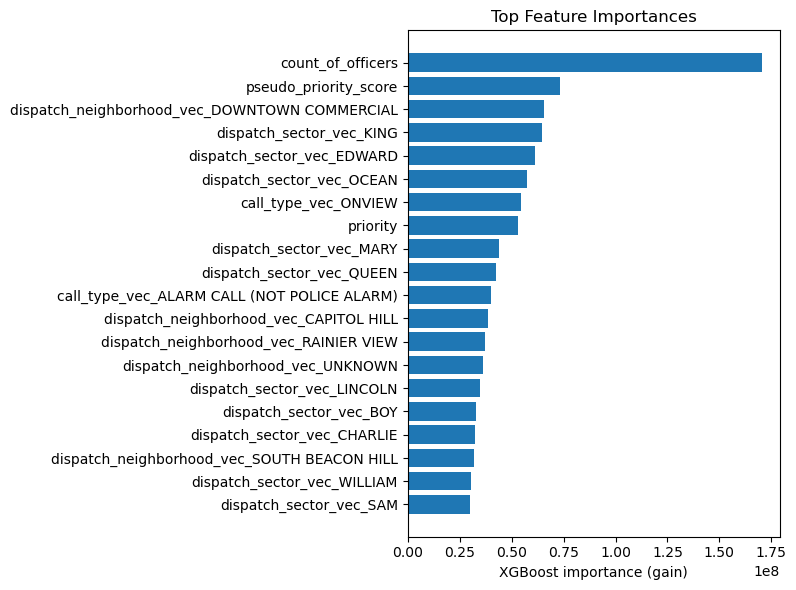

In [25]:
# ---- Build readable feature-name map from Spark metadata ----
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd
import matplotlib.pyplot as plt

# 1) pull ML attribute metadata from the prepared dataframe
meta = prepared.schema["features"].metadata
attrs = {}
for k in ["numeric", "binary"]:
    if "ml_attr" in meta and "attrs" in meta["ml_attr"] and k in meta["ml_attr"]["attrs"]:
        for a in meta["ml_attr"]["attrs"][k]:
            attrs[a["idx"]] = a["name"]

# 2) get raw importance from the XGBoost Spark model
booster = xgb_model.get_booster()
# choose one: 'weight' (#splits), 'gain' (avg gain), 'total_gain', 'cover', 'total_cover'
raw_imp = booster.get_score(importance_type="gain")  # dict like {'f12': 0.123, ...}

# 3) map f{idx} -> readable name
rows = []
for fid, val in raw_imp.items():
    idx = int(fid[1:])  # remove leading 'f'
    name = attrs.get(idx, fid)
    rows.append((name, idx, float(val)))

imp_df = pd.DataFrame(rows, columns=["feature","index","importance"]).sort_values("importance", ascending=False)

# 4) plot top-k
topk = 20
plt.figure(figsize=(8, 6))
plt.barh(imp_df.head(topk)["feature"][::-1], imp_df.head(topk)["importance"][::-1])
plt.xlabel("XGBoost importance (gain)")
plt.title("Top Feature Importances")
plt.tight_layout()
plt.show()

In [26]:
df.select("dispatch_sector").distinct().show()

+---------------+
|dispatch_sector|
+---------------+
|          UNION|
|         EDWARD|
|          DAVID|
|         GEORGE|
|           JOHN|
|           MARY|
|           NORA|
|           KING|
|         ROBERT|
|          QUEEN|
|        CHARLIE|
|          OCEAN|
|          FRANK|
|        LINCOLN|
|        WILLIAM|
|            OOJ|
|            SAM|
|            BOY|
|         HARBOR|
+---------------+

